# Word Embeddings

## The Distributional Hypothesis
*"You shall know a word by the company it keeps."* J.R. Firth, 1957

Words that appear in similar contexts have similar meanings. This is the foundation of word embeddings representing words as dense vectors in a continuous space where **similar words are geometrically close**.

## Why Embeddings?
- **One-hot vectors**: Sparse, high-dimensional, no semantic relationship
- **Embeddings**: Dense, low-dimensional (50-300d), capture semantic similarity
- Enable arithmetic: `king - man + woman ≈ queen`

---

## 1. Word2Vec (Mikolov et al., 2013)

Two architectures:

### 1.1 CBOW (Continuous Bag of Words)
**Predicts the target word from its context words.**

Given context words $w_{t-m}, ..., w_{t-1}, w_{t+1}, ..., w_{t+m}$, predict $w_t$.

$$P(w_t | \text{context}) = \text{softmax}(h \cdot W'^T)$$

where $h$ = average of context word vectors.

### 1.2 Skip-gram
**Predicts context words from the target word.**

Given $w_t$, predict $w_{t+j}$ for $-m \leq j \leq m, j \neq 0$.

### Objective Function (Skip-gram):
$$J = -\frac{1}{T} \sum_{t=1}^{T} \sum_{\substack{-m \leq j \leq m \\ j \neq 0}} \log P(w_{t+j} | w_t)$$

$$P(w_O | w_I) = \frac{\exp(v_{w_O}^T v_{w_I})}{\sum_{w=1}^{W} \exp(v_w^T v_{w_I})}$$

### Negative Sampling
The full softmax over vocabulary $W$ is expensive. **Negative sampling** approximates it:

$$J_{NS} = \log \sigma(v_{w_O}^T v_{w_I}) + \sum_{k=1}^{K} \mathbb{E}_{w_k \sim P_n(w)} [\log \sigma(-v_{w_k}^T v_{w_I})]$$

Sample $K$ negative words from noise distribution $P_n(w) \propto U(w)^{3/4}$ (unigram raised to 3/4 power).

---

## 2. GloVe (Pennington et al., 2014)

GloVe (**Glo**bal **Ve**ctors) combines global matrix factorization with local context window methods.

### Co-occurrence Matrix
$X_{ij}$ = number of times word $j$ appears in context of word $i$.

### Key Insight:
$$\frac{P(k|i)}{P(k|j)} \text{ encodes semantic relationships}$$

### GloVe Objective:
$$J = \sum_{i,j=1}^{V} f(X_{ij}) \left( w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2$$

where $f(X_{ij})$ is a weighting function:
$$f(x) = \begin{cases} (x/x_{\max})^\alpha & \text{if } x < x_{\max} \\ 1 & \text{otherwise} \end{cases}$$

with $x_{\max} = 100$, $\alpha = 3/4$.

---

## 3. FastText (Bojanowski et al., 2017)

Extension of Word2Vec that represents each word as a **bag of character n-grams**.

For word `where` with n=3: `<wh`, `whe`, `her`, `ere`, `re>` + `<where>`

$$\text{score}(w, c) = \sum_{g \in G_w} z_g^T v_c$$

**Advantages**: Handles OOV words, works well for morphologically rich languages.

---

## 4. ELMo (Peters et al., 2018)

**Contextualized embeddings** the same word gets different vectors based on context.

BiLSTM language model trained on large corpus:
$$\text{ELMo}_k^{task} = E(R_k; \Theta^{task}) = \gamma^{task} \sum_{j=0}^{L} s_j^{task} h_{k,j}^{LM}$$

Precursor to BERT and modern contextual embeddings.

---

## 5. Evaluation

### Word Analogy Task:
$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

Solved by finding: $\arg\max_{v \neq v_{king}, v_{man}, v_{woman}} \cos(v, \vec{king} - \vec{man} + \vec{woman})$

### Word Similarity:
Correlation between embedding cosine similarity and human judgments (WordSim353, SimLex-999).

### Cosine Similarity:
$$\cos(\theta) = \frac{A \cdot B}{||A|| \cdot ||B||} = \frac{\sum_i A_i B_i}{\sqrt{\sum_i A_i^2} \sqrt{\sum_i B_i^2}}$$

In [1]:
# Install: pip install gensim
import numpy as np
from gensim.models import Word2Vec, FastText
from gensim.models.keyedvectors import KeyedVectors
import re

# Sample corpus
sentences = [
    ["the", "king", "rules", "the", "kingdom"],
    ["the", "queen", "rules", "the", "kingdom"],
    ["the", "man", "is", "strong"],
    ["the", "woman", "is", "strong"],
    ["the", "prince", "will", "become", "king"],
    ["the", "princess", "will", "become", "queen"],
    ["deep", "learning", "is", "powerful"],
    ["machine", "learning", "is", "powerful"],
    ["neural", "networks", "power", "deep", "learning"],
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "dog", "sat", "on", "the", "floor"],
    ["paris", "is", "the", "capital", "of", "france"],
    ["berlin", "is", "the", "capital", "of", "germany"],
    ["london", "is", "the", "capital", "of", "england"],
]

print(f"Corpus: {len(sentences)} sentences")

Corpus: 14 sentences


In [2]:
# ============================================================
# WORD2VEC - Skip-gram
# ============================================================
sg_model = Word2Vec(
    sentences=sentences,
    vector_size=50,    # Embedding dimension
    window=2,          # Context window size
    min_count=1,       # Minimum word frequency
    sg=1,              # 1=Skip-gram, 0=CBOW
    negative=5,        # Number of negative samples
    epochs=200,
    seed=42
)

print("Skip-gram Word2Vec trained!")
print(f"Vocabulary size: {len(sg_model.wv.key_to_index)}")
print(f"Embedding dimension: {sg_model.wv.vector_size}")
print(f"\nVector for 'king' (first 10 dims): {sg_model.wv['king'][:10].round(4)}")

Skip-gram Word2Vec trained!
Vocabulary size: 34
Embedding dimension: 50

Vector for 'king' (first 10 dims): [ 0.0214 -0.015  -0.0148  0.0193  0.0022 -0.0011  0.0051 -0.0034 -0.0165
  0.0097]


In [3]:
# ============================================================
# WORD2VEC - CBOW
# ============================================================
cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=2,
    min_count=1,
    sg=0,   # CBOW
    epochs=200,
    seed=42
)

# Similarity
print("Cosine similarities (Skip-gram):")
pairs = [("king", "queen"), ("king", "man"), ("deep", "machine"), ("cat", "dog"), ("paris", "berlin")]
for w1, w2 in pairs:
    try:
        sim = sg_model.wv.similarity(w1, w2)
        print(f"  sim('{w1}', '{w2}') = {sim:.4f}")
    except KeyError as e:
        print(f"  Word not in vocab: {e}")

# Most similar words
print("\nMost similar to 'king':")
for word, score in sg_model.wv.most_similar('king', topn=5):
    print(f"  {word}: {score:.4f}")

Cosine similarities (Skip-gram):
  sim('king', 'queen') = 0.1679
  sim('king', 'man') = 0.1847
  sim('deep', 'machine') = 0.1035
  sim('cat', 'dog') = 0.1192
  sim('paris', 'berlin') = 0.0069

Most similar to 'king':
  is: 0.4100
  neural: 0.3754
  germany: 0.3264
  the: 0.2955
  power: 0.2858


In [4]:
# ============================================================
# WORD ANALOGY: king - man + woman = ?
# ============================================================
try:
    result = sg_model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
    print("king - man + woman = ?")
    for word, score in result:
        print(f"  {word}: {score:.4f}")
except Exception as e:
    print(f"Note: Small corpus limits analogy quality. Use pretrained vectors for best results: {e}")

# Doesn't match word relationship
try:
    result = sg_model.wv.most_similar(positive=['paris', 'germany'], negative=['france'], topn=3)
    print("\nparis - france + germany = ?")
    for word, score in result:
        print(f"  {word}: {score:.4f}")
except Exception as e:
    print(f"Analogy: {e}")

king - man + woman = ?
  learning: 0.3677
  power: 0.3264
  deep: 0.3256

paris - france + germany = ?
  king: 0.3162
  woman: 0.3108
  kingdom: 0.2678


In [5]:
# ============================================================
# FASTTEXT
# ============================================================
ft_model = FastText(
    sentences=sentences,
    vector_size=50,
    window=2,
    min_count=1,
    min_n=3,    # Minimum character n-gram size
    max_n=6,    # Maximum character n-gram size
    epochs=200,
    seed=42
)

print("FastText trained!")

# FastText handles OOV (out-of-vocabulary) words via character n-grams
oov_words = ["kingdoms", "queenly", "kingly", "deeplearning"]
print("\nFastText handles OOV words via subword information:")
for word in oov_words:
    vec = ft_model.wv[word]  # Won't throw error even for OOV
    print(f"  '{word}' vector norm: {np.linalg.norm(vec):.4f} (vector exists!)")

print("\nNote: Word2Vec would throw KeyError for OOV words, FastText doesn't!")

FastText trained!

FastText handles OOV words via subword information:
  'kingdoms' vector norm: 0.0195 (vector exists!)
  'queenly' vector norm: 0.0199 (vector exists!)
  'kingly' vector norm: 0.0208 (vector exists!)
  'deeplearning' vector norm: 0.0186 (vector exists!)

Note: Word2Vec would throw KeyError for OOV words, FastText doesn't!


In [6]:
# ============================================================
# COSINE SIMILARITY FROM SCRATCH
# ============================================================
def cosine_similarity(v1, v2):
    """Compute cosine similarity between two vectors"""
    dot = np.dot(v1, v2)
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    return dot / (norm + 1e-8)

v_king = sg_model.wv['king']
v_queen = sg_model.wv['queen']
v_dog = sg_model.wv['dog']

print("Cosine similarity (from scratch):")
print(f"  sim(king, queen) = {cosine_similarity(v_king, v_queen):.4f}")
print(f"  sim(king, dog)   = {cosine_similarity(v_king, v_dog):.4f}")

# Euclidean distance
print("\nEuclidean distance:")
print(f"  dist(king, queen) = {np.linalg.norm(v_king - v_queen):.4f}")
print(f"  dist(king, dog)   = {np.linalg.norm(v_king - v_dog):.4f}")

Cosine similarity (from scratch):
  sim(king, queen) = 0.1679
  sim(king, dog)   = 0.0960

Euclidean distance:
  dist(king, queen) = 0.1149
  dist(king, dog)   = 0.1148


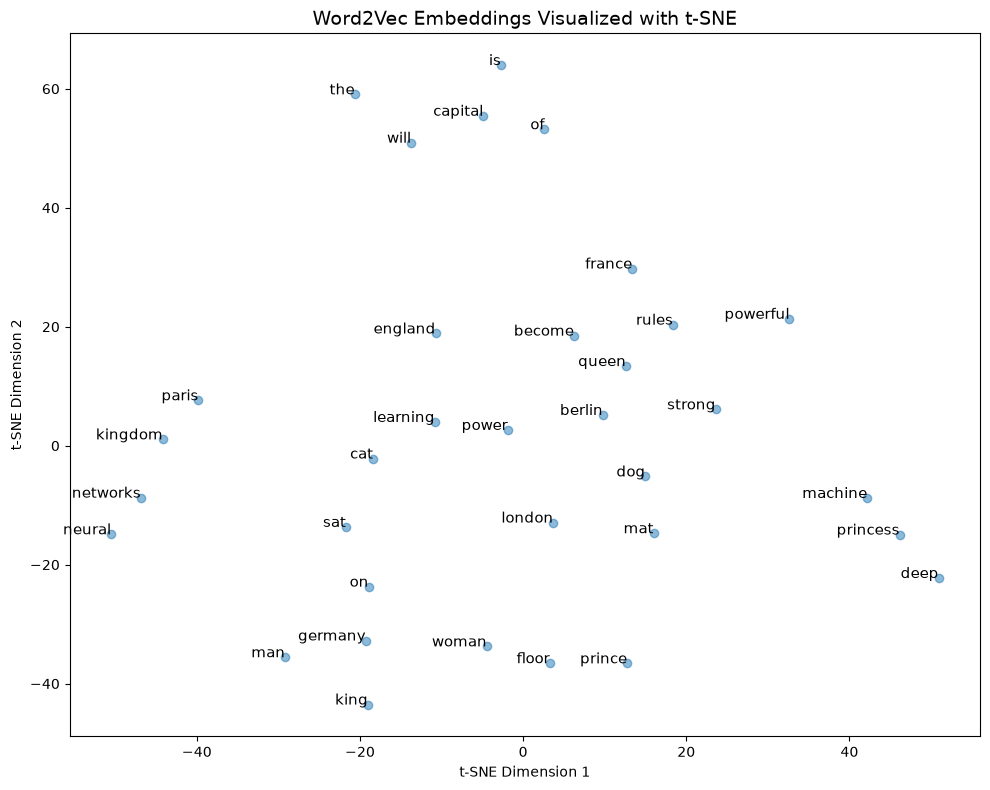

Semantically related words cluster together in embedding space!


In [7]:
# ============================================================
# VISUALIZE EMBEDDINGS WITH t-SNE
# ============================================================
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Get all word vectors
words = list(sg_model.wv.key_to_index.keys())
vectors = np.array([sg_model.wv[w] for w in words])

# t-SNE to reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(vectors)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5)

for i, word in enumerate(words):
    ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
               fontsize=11, ha='right')

ax.set_title('Word2Vec Embeddings Visualized with t-SNE', fontsize=14)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

print("Semantically related words cluster together in embedding space!")

In [8]:
# ============================================================
# LOADING PRETRAINED EMBEDDINGS
# ============================================================
print("Loading pretrained embeddings (examples):")
print()
print("# Load GloVe (download from https://nlp.stanford.edu/projects/glove/)")
print("# from gensim.scripts.glove2word2vec import glove2word2vec")
print("# glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.word2vec.txt')")
print("# glove_model = KeyedVectors.load_word2vec_format('glove.6B.100d.word2vec.txt')")
print()
print("# Load Word2Vec pretrained (Google News)")
print("# from gensim.models import KeyedVectors")
print("# model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)")
print()
print("# Using Hugging Face sentence-transformers (contextual, modern)")
print("# from sentence_transformers import SentenceTransformer")
print("# model = SentenceTransformer('all-MiniLM-L6-v2')")
print("# embeddings = model.encode(['Hello world', 'How are you?'])")

Loading pretrained embeddings (examples):

# Load GloVe (download from https://nlp.stanford.edu/projects/glove/)
# from gensim.scripts.glove2word2vec import glove2word2vec
# glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.word2vec.txt')
# glove_model = KeyedVectors.load_word2vec_format('glove.6B.100d.word2vec.txt')

# Load Word2Vec pretrained (Google News)
# from gensim.models import KeyedVectors
# model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)

# Using Hugging Face sentence-transformers (contextual, modern)
# from sentence_transformers import SentenceTransformer
# model = SentenceTransformer('all-MiniLM-L6-v2')
# embeddings = model.encode(['Hello world', 'How are you?'])


In [9]:
# ============================================================
# SENTENCE EMBEDDINGS with Sentence Transformers
# ============================================================
try:
    from sentence_transformers import SentenceTransformer, util
    
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    sentences_test = [
        "The cat sits on the mat",
        "A feline is resting on the rug",
        "Deep learning is a subset of machine learning",
        "Neural networks are powerful AI models",
        "The weather is nice today"
    ]
    
    embeddings = model.encode(sentences_test)
    print(f"Sentence embedding shape: {embeddings.shape}")
    
    # Compute pairwise similarities
    similarity_matrix = util.cos_sim(embeddings, embeddings)
    
    print("\nPairwise sentence similarities:")
    for i in range(len(sentences_test)):
        for j in range(i+1, len(sentences_test)):
            sim = similarity_matrix[i][j].item()
            if sim > 0.4:
                print(f"  [{sim:.3f}] '{sentences_test[i][:30]}...' ↔ '{sentences_test[j][:30]}...'")

except ImportError:
    print("Install: pip install sentence-transformers")

Sentence embedding shape: (5, 384)

Pairwise sentence similarities:
  [0.588] 'The cat sits on the mat...' ↔ 'A feline is resting on the rug...'
  [0.496] 'Deep learning is a subset of m...' ↔ 'Neural networks are powerful A...'


## Additional Learning Resources

### Original Papers
- [Word2Vec: Efficient Estimation of Word Representations in Vector Space](https://arxiv.org/abs/1301.3781) Mikolov et al., 2013
- [Distributed Representations of Words and Phrases](https://arxiv.org/abs/1310.4546) Mikolov et al., 2013 (negative sampling)
- [GloVe: Global Vectors for Word Representation](https://nlp.stanford.edu/pubs/glove.pdf) Pennington et al., 2014
- [FastText: Enriching Word Vectors with Subword Information](https://arxiv.org/abs/1607.04606) Bojanowski et al., 2017
- [ELMo: Deep Contextualized Word Representations](https://arxiv.org/abs/1802.05365) Peters et al., 2018

### Resources
- [GloVe Project Page](https://nlp.stanford.edu/projects/glove/) Download pretrained vectors
- [gensim Documentation](https://radimrehurek.com/gensim/) Python NLP library
- [Sentence Transformers Docs](https://www.sbert.net/) State-of-the-art sentence embeddings
- [The Illustrated Word2Vec](https://jalammar.github.io/illustrated-word2vec/) Jay Alammar's visual guide

### Courses
- [Stanford CS224n Lecture 1-3](https://web.stanford.edu/class/cs224n/) Word vectors
- [fast.ai NLP](https://www.fast.ai/) Practical embeddings
- [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) Best current embedding models